In [29]:
import warnings
import os
import pandas as pd
import numpy as np
import torch
import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from lightning.pytorch.tuner import Tuner
import matplotlib.pyplot as plt


from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer, Baseline
from pytorch_forecasting.data import NaNLabelEncoder
from pytorch_forecasting.data.encoders import MultiNormalizer, TorchNormalizer
from pytorch_forecasting.metrics import QuantileLoss, MAE, SMAPE
from sklearn.model_selection import train_test_split


warnings.filterwarnings("ignore")
torch.set_default_dtype(torch.float32)


# Constants
path = "/Users/darenpalmer/Desktop/UCL/CS/fyp.nosync/data/carOBD/obdiidata"
sensor_cols = [
    'COOLANT_TEMPERATURE ()',
    'ENGINE_RPM ()',
    'VEHICLE_SPEED ()',
    'THROTTLE ()',
    'ENGINE_LOAD ()',
    'INTAKE_MANIFOLD_PRESSURE ()',
]
id_col = "drive_id"
time_col = 'ENGINE_RUN_TINE ()'
window_size = 300     # 300
forecast_horizon = 1

# %%
df_list = []
for file in os.listdir(path):
    if file.endswith('.csv'):
        df = pd.read_csv(f'{path}/{file}', index_col=False)
        df['drive_id'] = file
        df_list.append(df)


print(f'{len(df_list)} files loaded out of {len([f for f in os.listdir(path) if f.endswith(".csv")])}')


# %%
def remove_zero_variance_columns(df: pd.DataFrame, exclude_cols: list[str] = None) -> pd.DataFrame:
    """
    Compute std of each std-computable column (numeric only)
    """
    if exclude_cols is None:
        exclude_cols = []
    
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    cols_to_check = [col for col in numeric_cols if col not in exclude_cols]
  
    std_df = df[cols_to_check].std()
    zero_variance_cols = std_df[std_df == 0].index.tolist()
  
    print(f'{len(zero_variance_cols)} columns with zero variance: {zero_variance_cols}')
  
    if len(zero_variance_cols) > 0:
        df = df.drop(columns=zero_variance_cols)
  
    return df


# %%
def mean_fill_missing_timestamps_and_remove_duplicates(df: pd.DataFrame, time_col: str, id_cols: list[str] = None) -> pd.DataFrame:
    """
    Remove duplicate timestamps by averaging all numeric columns for each unique timestamp.
    This preserves the overall statistics while removing duplicate entries.
    
    Note: The time column itself is not averaged (it becomes the group key).
    Only numeric columns are averaged when multiple rows share the same timestamp.
    """
    if id_cols is None:
        id_cols = []
    
    existing_id_cols = [col for col in id_cols if col in df.columns]
    
    group_cols = [time_col] + existing_id_cols
    
    agg_dict = {}
    for col in df.columns:
        if col not in group_cols:
            if pd.api.types.is_numeric_dtype(df[col]):
                agg_dict[col] = 'mean'
            else:
                agg_dict[col] = 'first'
  
    df_clean = df.groupby(group_cols, as_index=False).agg(agg_dict)
  
    return df_clean


# %%
def downsample(df, time_col, source_file_col, downsample_factor=2):
    result_dfs = []
    
    for source_file in df[source_file_col].unique():
        file_df = df[df[source_file_col] == source_file].copy()
        
        if len(file_df) < downsample_factor * 2:
            continue
        
        file_df = file_df.sort_values(time_col).reset_index(drop=True)
        
        # Simple decimation without pre-smoothing
        downsampled = file_df.iloc[::downsample_factor].copy()
        downsampled[time_col] = np.arange(len(downsampled)) * downsample_factor
        
        result_dfs.append(downsampled.reset_index(drop=True))
    
    return pd.concat(result_dfs, ignore_index=True)


# %%
def filter_long_drives(df, id_col='drive_id', min_length=608):
    """Keep only drives long enough for your context window"""
    drive_lengths = df.groupby(id_col).size()
    valid_drives = drive_lengths[drive_lengths >= min_length].index
    
    print(f"Keeping {len(valid_drives)}/{df[id_col].nunique()} drives")
    print(f"Dropped {len(df) - df[df[id_col].isin(valid_drives)].shape[0]} timesteps")
    
    return df[df[id_col].isin(valid_drives)].reset_index(drop=True)


# %%
# Combine all dataframes
data = pd.concat(df_list, ignore_index=True)


# Clean up
print(f"Total samples: {len(data):,}")
print(f"Unique drives: {data['drive_id'].nunique()}")


# remove some useless columns
data = data.drop(columns=['WARM_UPS_SINCE_CODES_CLEARED ()', 'TIME_SINCE_TROUBLE_CODES_CLEARED ()'])


data = mean_fill_missing_timestamps_and_remove_duplicates(data, time_col=time_col, id_cols=["drive_id"])
data = remove_zero_variance_columns(data, exclude_cols=["drive_id"])
data = downsample(
    data,
    time_col=time_col,
    source_file_col='drive_id',
    downsample_factor=1
)


data = filter_long_drives(data, min_length=context_length + forecast_length)


# %%
def add_cross_channel_features(data, target_columns):
    """
    Engineer features that capture cross-channel relationships.
    Add these as conditional columns.
    """
    # RPM-to-Speed ratio (gear indicator)
    if 'ENGINE_RPM ()' in data.columns and 'VEHICLE_SPEED ()' in data.columns:
        data['RPM_SPEED_RATIO'] = data['ENGINE_RPM ()'] / (data['VEHICLE_SPEED ()'] + 1)
    
    # Throttle-to-Load ratio (efficiency indicator)
    if 'THROTTLE ()' in data.columns and 'ENGINE_LOAD ()' in data.columns:
        data['THROTTLE_LOAD_RATIO'] = data['THROTTLE ()'] / (data['ENGINE_LOAD ()'] + 1)
    
    # Speed-based categories
    if 'VEHICLE_SPEED ()' in data.columns:
        data['IS_IDLE'] = (data['VEHICLE_SPEED ()'] < 5).astype(float)
        data['IS_HIGHWAY'] = (data['VEHICLE_SPEED ()'] > 60).astype(float)
    
    # RPM acceleration
    if 'ENGINE_RPM ()' in data.columns:
        data['RPM_ACCEL'] = data.groupby('drive_id')['ENGINE_RPM ()'].diff().fillna(0)
    
    return data


# Apply cross-channel features before preprocessing
data = add_cross_channel_features(data, target_columns)
print("Added cross-channel features")


# %%
import numpy as np
import pandas as pd


# Ensure data is sorted
data = data.sort_values(["drive_id", time_col]).reset_index(drop=True)


# Get unique drive IDs
unique_drives = data['drive_id'].unique()
n_drives = len(unique_drives)


# Split drives into train/val/test groups (70/15/15)
train_drives = unique_drives[:int(0.70 * n_drives)]
val_drives   = unique_drives[int(0.70 * n_drives):int(0.85 * n_drives)]
test_drives  = unique_drives[int(0.85 * n_drives):]


print(f"Train drives: {len(train_drives)}, Val drives: {len(val_drives)}, Test drives: {len(test_drives)}")


# Create split dataframes
train_data = data[data['drive_id'].isin(train_drives)].copy()
val_data   = data[data['drive_id'].isin(val_drives)].copy()
test_data  = data[data['drive_id'].isin(test_drives)].copy()


print(f"Train shape: {train_data.shape}, Val shape: {val_data.shape}, Test shape: {test_data.shape}")

129 files loaded out of 129
Total samples: 304,299
Unique drives: 129
3 columns with zero variance: ['FUEL_AIR_COMMANDED_EQUIV_RATIO ()', 'TIME_RUN_WITH_MIL_ON ()', 'DISTANCE_TRAVELED_WITH_MIL_ON ()']
Keeping 106/129 drives
Dropped 6490 timesteps
Added cross-channel features
Train drives: 74, Val drives: 16, Test drives: 16
Train shape: (47832, 28), Val shape: (18384, 28), Test shape: (9701, 28)


In [ ]:
from faults import create_realistic_fault_data
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import MinMaxScaler

def build_windows(df, sensor_cols, id_col, time_col, window_size, horizon=1, fault_percentage=0.0, scaler=None):
    df = df.copy()
    
    if fault_percentage > 0:
        vals = df[sensor_cols].values
        vals_faulty, labels, metadata = create_realistic_fault_data(vals, fault_percentage=fault_percentage)
        df[sensor_cols] = vals_faulty

    df = df.sort_values([id_col, time_col])
    df_sensors = df[[id_col, time_col] + sensor_cols].copy()

    if scaler is None:
        scaler = MinMaxScaler()
        df_sensors[sensor_cols] = scaler.fit_transform(df_sensors[sensor_cols])
    else:
        df_sensors[sensor_cols] = scaler.transform(df_sensors[sensor_cols])

    X_list, y_list = [], []

    for drive_id, group in df_sensors.groupby(id_col):
        values = group[sensor_cols].values
        T_, num_sensors = values.shape
        if T_ <= window_size + horizon:
            continue

        for t in range(T_ - window_size - horizon + 1):
            X_window = values[t : t + window_size]
            y_target = values[t + window_size + horizon - 1]

            X_list.append(X_window)
            y_list.append(y_target)

    X = torch.tensor(np.stack(X_list), dtype=torch.float32)
    y = torch.tensor(np.stack(y_list), dtype=torch.float32)
    return X, y, scaler

X_train, y_train, scaler_train = build_windows(train_data, sensor_cols, id_col, time_col, window_size, fault_percentage=0.0)

X_val,   y_val,   _            = build_windows(val_data,   sensor_cols, id_col, time_col, window_size, fault_percentage=0.0, scaler=scaler_train)

X_test,  y_test,  _            = build_windows(test_data,  sensor_cols, id_col, time_col, window_size, fault_percentage=0.2, scaler=scaler_train)

train_ds = TensorDataset(X_train, y_train)
val_ds   = TensorDataset(X_val, y_val)
test_ds  = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=32, shuffle=False)

num_sensors = len(sensor_cols)
print("Train windows:", len(train_ds), "Sensors:", num_sensors)


Train windows: 25632 Sensors: 6


In [31]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv

class SimpleGDN(nn.Module):
    def __init__(self, num_nodes, window_size, hidden_dim=64):
        super().__init__()
        self.num_nodes = num_nodes
        self.window_size = window_size

        self.temporal_embed = nn.Linear(window_size, hidden_dim)

        src, dst = torch.meshgrid(
            torch.arange(num_nodes), torch.arange(num_nodes), indexing='ij'
        )
        edge_index = torch.stack([src.reshape(-1), dst.reshape(-1)], dim=0)
        self.register_buffer("edge_index", edge_index)

        self.gnn = GATConv(hidden_dim, hidden_dim, heads=1, concat=False)

        self.out = nn.Sequential(
            nn.Linear(hidden_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        B, T, N = x.shape
        assert T == self.window_size and N == self.num_nodes

        x = x.permute(0, 2, 1).reshape(B * N, T)

        h = F.relu(self.temporal_embed(x))
        h = h.reshape(B, N, -1)

        outputs = []
        for i in range(B):
            node_feats = h[i]
            gnn_out = self.gnn(node_feats, self.edge_index)
            outputs.append(gnn_out)

        outputs = torch.stack(outputs, dim=0)
        preds = self.out(outputs).squeeze(-1)
        return preds


In [ ]:
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
model = SimpleGDN(num_nodes=num_sensors, window_size=window_size).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

def run_epoch(loader, train=True):
    if train:
        model.train()
    else:
        model.eval()
    total_loss = 0.0
    with torch.set_grad_enabled(train):
        for X_batch, y_batch in tqdm(loader):
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            if train:
                optimizer.zero_grad()
            preds = model(X_batch)
            loss = criterion(preds, y_batch)
            if train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * X_batch.size(0)
    return total_loss / len(loader.dataset)

for epoch in range(10):
    train_loss = run_epoch(train_loader, train=True)
    val_loss   = run_epoch(val_loader, train=False)
    print(f"Epoch {epoch+1}: train {train_loss:.6f}  val {val_loss:.6f}")


100%|██████████| 425/425 [00:22<00:00, 19.16it/s]


Epoch 1: train 0.046938  val 0.032828


100%|██████████| 425/425 [00:21<00:00, 19.41it/s]


Epoch 2: train 0.014102  val 0.020436


100%|██████████| 425/425 [00:22<00:00, 18.91it/s]


...

Epoch 8: train 0.008531  val 0.021262


100%|██████████| 425/425 [00:23<00:00, 17.72it/s]


Epoch 9: train 0.008474  val 0.024722


100%|██████████| 425/425 [00:23<00:00, 18.31it/s]

Epoch 10: train 0.008258  val 0.022198


In [46]:
model.eval()
all_errors = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        preds = model(X_batch)
        # per-sensor absolute error
        errors = torch.abs(preds - y_batch)   # [B, N]
        all_errors.append(errors.cpu())

all_errors = torch.cat(all_errors, dim=0)     # [num_windows, num_sensors]

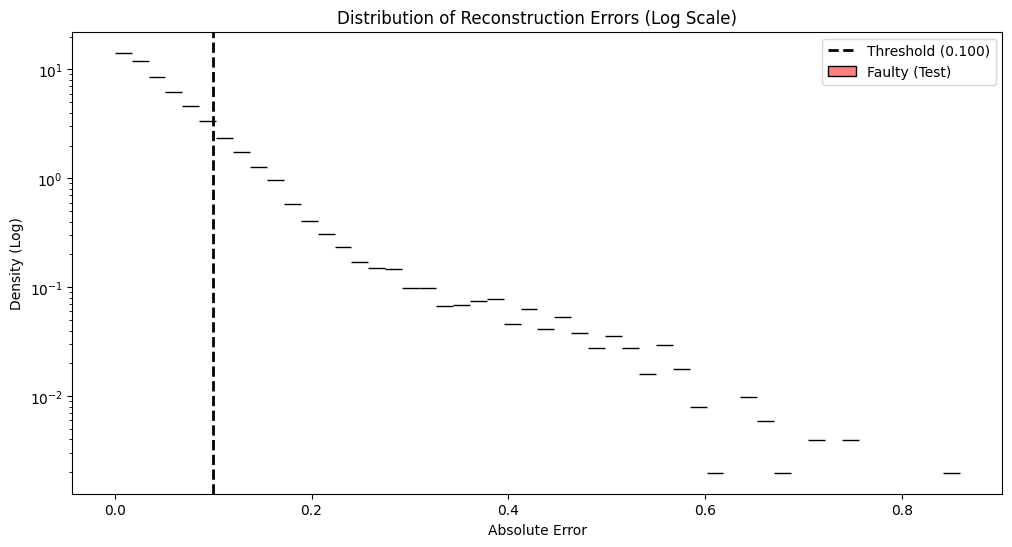

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
import torch

threshold = 0.1
test_err_flat = all_errors.flatten().numpy()

plt.figure(figsize=(12, 6))


# Plot Faulty Test Errors
sns.histplot(test_err_flat, bins=50, color='red', alpha=0.5, label='Faulty (Test)', stat='density', log_scale=(False, True))

# Add threshold line
plt.axvline(threshold, color='black', linestyle='--', linewidth=2, label=f'Threshold ({threshold:.3f})')

plt.title("Distribution of Reconstruction Errors (Log Scale)")
plt.xlabel("Absolute Error")
plt.ylabel("Density (Log)")
plt.legend()
plt.show()

In [48]:
anomalies = (all_errors > threshold).sum(dim=1)
anomaly_rate = (anomalies > 0).float().mean()
print(f"Anomaly rate: {anomaly_rate:.3f}")


Anomaly rate: 0.587
